# NLP Assignment
**Roll Number:** 23F0017  
**Dataset:** Twitter Sentiment (Odd Roll Number)

## Setup & GPU Check

In [1]:
# Step 1: Install correct PyTorch for Kaggle P100 (CUDA 12.1)
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,driver_version', '--format=csv,noheader'], capture_output=True, text=True)
print('GPU Info:', result.stdout.strip())

GPU Info: Tesla T4, 580.105.08
Tesla T4, 580.105.08


In [2]:
# Do NOT reinstall torch - Kaggle P100 already has the correct version
# Just install the other libraries we need
!pip install -q datasets transformers scikit-learn gensim nltk matplotlib seaborn
print('Libraries installed.')


Libraries installed.


In [3]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU name:', torch.cuda.get_device_name(0))
    # Warm up GPU with a silent operation - do not print cuda tensor
    _ = torch.zeros(1).cuda() + torch.zeros(1).cuda()
    torch.cuda.synchronize()
    print('GPU warm-up OK')
else:
    print('WARNING: No GPU found, running on CPU')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4
GPU warm-up OK
Using device: cuda


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import string
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('All imports done.')

Using device: cuda
All imports done.


## Load Dataset

In [5]:
from datasets import load_dataset

dataset = load_dataset('tweet_eval', 'sentiment')

train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

print('Train size:', len(train_df))
print('Test size:', len(test_df))
print(train_df.head())
print('\nLabel counts (0=neg, 1=neutral, 2=pos):')
print(train_df['label'].value_counts())

README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train size: 45615
Test size: 12284
                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2

Label counts (0=neg, 1=neutral, 2=pos):
label
1    20673
2    17849
0     7093
Name: count, dtype: int64


In [6]:
X_train_raw = train_df['text'].tolist()
y_train     = train_df['label'].tolist()
X_test_raw  = test_df['text'].tolist()
y_test      = test_df['label'].tolist()

print('Sample tweet:', X_train_raw[0])
print('Label:', y_train[0])

Sample tweet: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Label: 2


## Preprocessing

In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and t.strip() != '']
    return ' '.join(tokens)

X_train_clean = [clean_text(t) for t in X_train_raw]
X_test_clean  = [clean_text(t) for t in X_test_raw]

print('Original:', X_train_raw[0])
print('Cleaned: ', X_train_clean[0])

Original: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Cleaned:  qt original draft 7th book remus lupin survived battle hogwarts happybirthdayremuslupin


---
# Module 1: Frequency-Based Embeddings

## Bag of Words

In [8]:
bow_vectorizer = CountVectorizer(max_features=10000)
X_train_bow = bow_vectorizer.fit_transform(X_train_clean)
X_test_bow  = bow_vectorizer.transform(X_test_clean)
print('BoW train shape:', X_train_bow.shape)

BoW train shape: (45615, 10000)


In [9]:
bow_model = LogisticRegression(max_iter=1000, random_state=42)
bow_model.fit(X_train_bow, y_train)
bow_preds = bow_model.predict(X_test_bow)

bow_acc  = accuracy_score(y_test, bow_preds)
bow_prec = precision_score(y_test, bow_preds, average='weighted', zero_division=0)
bow_rec  = recall_score(y_test, bow_preds, average='weighted', zero_division=0)
bow_f1   = f1_score(y_test, bow_preds, average='weighted', zero_division=0)

print('=== BoW Results ===')
print(f'Accuracy:  {bow_acc:.4f}')
print(f'Precision: {bow_prec:.4f}')
print(f'Recall:    {bow_rec:.4f}')
print(f'F1 Score:  {bow_f1:.4f}')
print(classification_report(y_test, bow_preds, zero_division=0))

=== BoW Results ===
Accuracy:  0.5760
Precision: 0.5843
Recall:    0.5760
F1 Score:  0.5704
              precision    recall  f1-score   support

           0       0.64      0.42      0.51      3972
           1       0.59      0.69      0.64      5937
           2       0.48      0.55      0.51      2375

    accuracy                           0.58     12284
   macro avg       0.57      0.55      0.55     12284
weighted avg       0.58      0.58      0.57     12284



## TF-IDF

In [10]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_clean)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_clean)

tfidf_model = LogisticRegression(max_iter=1000, random_state=42)
tfidf_model.fit(X_train_tfidf, y_train)
tfidf_preds = tfidf_model.predict(X_test_tfidf)

tfidf_acc  = accuracy_score(y_test, tfidf_preds)
tfidf_prec = precision_score(y_test, tfidf_preds, average='weighted', zero_division=0)
tfidf_rec  = recall_score(y_test, tfidf_preds, average='weighted', zero_division=0)
tfidf_f1   = f1_score(y_test, tfidf_preds, average='weighted', zero_division=0)

print('=== TF-IDF Results ===')
print(f'Accuracy:  {tfidf_acc:.4f}')
print(f'Precision: {tfidf_prec:.4f}')
print(f'Recall:    {tfidf_rec:.4f}')
print(f'F1 Score:  {tfidf_f1:.4f}')
print(classification_report(y_test, tfidf_preds, zero_division=0))

=== TF-IDF Results ===
Accuracy:  0.5884
Precision: 0.6023
Recall:    0.5884
F1 Score:  0.5761
              precision    recall  f1-score   support

           0       0.68      0.37      0.48      3972
           1       0.59      0.75      0.66      5937
           2       0.51      0.56      0.53      2375

    accuracy                           0.59     12284
   macro avg       0.59      0.56      0.56     12284
weighted avg       0.60      0.59      0.58     12284



## Co-occurrence Matrix

In [11]:
from collections import Counter
from scipy.sparse import lil_matrix
from sklearn.decomposition import TruncatedSVD

# Build vocabulary (top 3000 words)
all_tokens = []
for text in X_train_clean:
    all_tokens.extend(text.split())

word_counts = Counter(all_tokens)
vocab       = [w for w, _ in word_counts.most_common(3000)]
word2idx    = {w: i for i, w in enumerate(vocab)}
vocab_size  = len(vocab)

# Build co-occurrence matrix (window=2)
cooc   = lil_matrix((vocab_size, vocab_size), dtype=np.float32)
window = 2

for text in X_train_clean:
    tokens = text.split()
    for i, word in enumerate(tokens):
        if word not in word2idx:
            continue
        for j in range(max(0, i - window), min(len(tokens), i + window + 1)):
            if j == i:
                continue
            context = tokens[j]
            if context in word2idx:
                cooc[word2idx[word], word2idx[context]] += 1

cooc = cooc.tocsr()
print('Co-occurrence matrix shape:', cooc.shape)

Co-occurrence matrix shape: (3000, 3000)


In [12]:
# Reduce to 100 dims with SVD
svd              = TruncatedSVD(n_components=100, random_state=42)
cooc_embeddings  = svd.fit_transform(cooc)

def text_to_cooc_vec(text):
    tokens = text.split()
    vecs   = [cooc_embeddings[word2idx[t]] for t in tokens if t in word2idx]
    if len(vecs) == 0:
        return np.zeros(100)
    return np.mean(vecs, axis=0)

X_train_cooc = np.array([text_to_cooc_vec(t) for t in X_train_clean])
X_test_cooc  = np.array([text_to_cooc_vec(t) for t in X_test_clean])

cooc_model = LogisticRegression(max_iter=1000, random_state=42)
cooc_model.fit(X_train_cooc, y_train)
cooc_preds = cooc_model.predict(X_test_cooc)

cooc_acc  = accuracy_score(y_test, cooc_preds)
cooc_prec = precision_score(y_test, cooc_preds, average='weighted', zero_division=0)
cooc_rec  = recall_score(y_test, cooc_preds, average='weighted', zero_division=0)
cooc_f1   = f1_score(y_test, cooc_preds, average='weighted', zero_division=0)

print('=== Co-occurrence Results ===')
print(f'Accuracy:  {cooc_acc:.4f}')
print(f'Precision: {cooc_prec:.4f}')
print(f'Recall:    {cooc_rec:.4f}')
print(f'F1 Score:  {cooc_f1:.4f}')

=== Co-occurrence Results ===
Accuracy:  0.4851
Precision: 0.4839
Recall:    0.4851
F1 Score:  0.4309


## Module 1 Observations

**Results:**
- BoW: Accuracy 0.5760, F1 0.5704
- TF-IDF: Accuracy 0.5884, F1 0.5761
- Co-occurrence: Accuracy 0.4851, F1 0.4309

TF-IDF was the best in Module 1. It outperforms plain BoW because it lowers the weight of very common words and raises the weight of rare but meaningful words. Co-occurrence with SVD performed worst here because the small training vocabulary (3000 words) and short tweet texts give very sparse context windows.

**Limitations of frequency-based methods:**

1. **No context.** BoW and TF-IDF treat each word independently. Word order is lost, so "not good" and "good" look similar.
2. **High dimensions.** Vocabulary of 10,000 words creates large sparse vectors.
3. **No semantic meaning.** Words like "happy" and "joyful" have totally different entries even though they mean the same thing.
4. **Rare words ignored.** Very infrequent words add noise with little signal.
5. **Co-occurrence needs long text.** Tweets are short, so co-occurrence windows rarely fire, making the vectors weak.

---
# Module 2: Prediction-Based Embeddings

## Train Word2Vec

In [13]:
from gensim.models import Word2Vec

train_sentences = [text.split() for text in X_train_clean]

w2v_model = Word2Vec(
    sentences=train_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=0,       # CBOW
    workers=4,
    epochs=10
)

print('Word2Vec vocabulary size:', len(w2v_model.wv))

Word2Vec vocabulary size: 20633


In [14]:
def text_to_w2v_vec(text, model, dim=100):
    tokens = text.split()
    vecs   = [model.wv[t] for t in tokens if t in model.wv]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_train_w2v = np.array([text_to_w2v_vec(t, w2v_model) for t in X_train_clean])
X_test_w2v  = np.array([text_to_w2v_vec(t, w2v_model) for t in X_test_clean])
print('W2V train shape:', X_train_w2v.shape)

W2V train shape: (45615, 100)


## Load GloVe Embeddings

In [15]:
import os
import subprocess

glove_file = 'glove_twitter/glove.twitter.27B.100d.txt'

if not os.path.exists(glove_file):
    print('Downloading GloVe Twitter embeddings (~400 MB)...')
    os.makedirs('glove_twitter', exist_ok=True)
    subprocess.run(['wget', '-q', 'https://nlp.stanford.edu/data/glove.twitter.27B.zip',
                    '-O', 'glove_twitter.zip'], check=True)
    subprocess.run(['unzip', '-q', 'glove_twitter.zip', '-d', 'glove_twitter'], check=True)
    print('Download done.')
else:
    print('GloVe already exists, skipping download.')

glove = {}
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype=np.float32)
        glove[word] = vec

print(f'GloVe loaded. Total words: {len(glove)}')


Download done.
GloVe loaded. Total words: 1193514


In [16]:
def text_to_glove_vec(text, glove_dict, dim=100):
    tokens = text.split()
    vecs   = [glove_dict[t] for t in tokens if t in glove_dict]
    if len(vecs) == 0:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

X_train_glove = np.array([text_to_glove_vec(t, glove) for t in X_train_clean])
X_test_glove  = np.array([text_to_glove_vec(t, glove) for t in X_test_clean])
print('GloVe train shape:', X_train_glove.shape)

GloVe train shape: (45615, 100)


## Feedforward Neural Network (GPU)

In [17]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Confirm GPU is alive before FNN training
print('Device:', device)
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    _ = torch.zeros(1).cuda()   # warm up
    print('GPU warm-up OK')

Device: cuda
GPU warm-up OK


In [18]:
class FNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


def train_fnn(X_tr, X_te, y_tr, y_te, epochs=15, lr=1e-3, batch_size=256):
    num_classes = len(set(y_tr))
    input_dim   = X_tr.shape[1]

    Xt = torch.FloatTensor(X_tr)
    yt = torch.LongTensor(y_tr)
    Xv = torch.FloatTensor(X_te)

    loader = DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=True)

    model     = FNN(input_dim, num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f}')

    model.eval()
    with torch.no_grad():
        preds = model(Xv.to(device)).argmax(dim=1).cpu().numpy()

    acc  = accuracy_score(y_te, preds)
    prec = precision_score(y_te, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_te, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_te, preds, average='weighted', zero_division=0)
    return acc, prec, rec, f1, preds

print('FNN class ready.')

FNN class ready.


In [19]:
print('Training FNN on Word2Vec...')
w2v_acc, w2v_prec, w2v_rec, w2v_f1, w2v_preds = train_fnn(
    X_train_w2v, X_test_w2v, y_train, y_test, epochs=15
)
print(f'\n=== Word2Vec FNN Results ===')
print(f'Accuracy:  {w2v_acc:.4f}')
print(f'Precision: {w2v_prec:.4f}')
print(f'Recall:    {w2v_rec:.4f}')
print(f'F1 Score:  {w2v_f1:.4f}')

Training FNN on Word2Vec...
  Epoch 5/15 | Loss: 0.8572
  Epoch 10/15 | Loss: 0.8413
  Epoch 15/15 | Loss: 0.8328

=== Word2Vec FNN Results ===
Accuracy:  0.5477
Precision: 0.5468
Recall:    0.5477
F1 Score:  0.5319


In [20]:
print('Training FNN on GloVe...')
glove_acc, glove_prec, glove_rec, glove_f1, glove_preds = train_fnn(
    X_train_glove, X_test_glove, y_train, y_test, epochs=15
)
print(f'\n=== GloVe FNN Results ===')
print(f'Accuracy:  {glove_acc:.4f}')
print(f'Precision: {glove_prec:.4f}')
print(f'Recall:    {glove_rec:.4f}')
print(f'F1 Score:  {glove_f1:.4f}')

Training FNN on GloVe...
  Epoch 5/15 | Loss: 0.7598
  Epoch 10/15 | Loss: 0.7347
  Epoch 15/15 | Loss: 0.7138

=== GloVe FNN Results ===
Accuracy:  0.6209
Precision: 0.6242
Recall:    0.6209
F1 Score:  0.6211


## Word Embedding Visualization

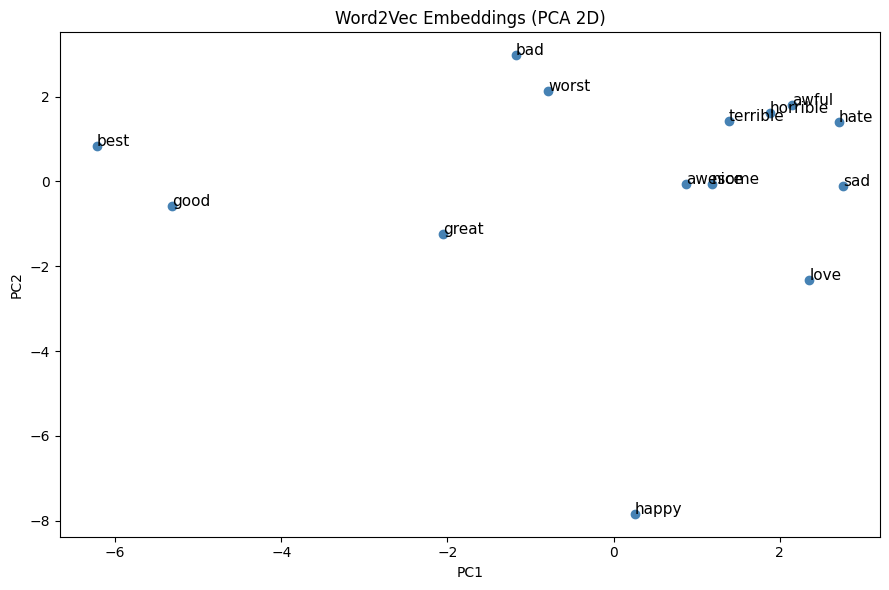

PCA plot saved.


In [21]:
# PCA on Word2Vec
words_to_plot = [
    'good', 'bad', 'happy', 'sad', 'love', 'hate',
    'great', 'terrible', 'awesome', 'awful',
    'nice', 'horrible', 'best', 'worst'
]

words_w2v = [w for w in words_to_plot if w in w2v_model.wv]
vecs_w2v  = np.array([w2v_model.wv[w] for w in words_w2v])

pca     = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(vecs_w2v)

plt.figure(figsize=(9, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], color='steelblue')
for i, word in enumerate(words_w2v):
    plt.annotate(word, (reduced[i, 0], reduced[i, 1]), fontsize=11)
plt.title('Word2Vec Embeddings (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('w2v_pca.png', dpi=100)
plt.show()
print('PCA plot saved.')

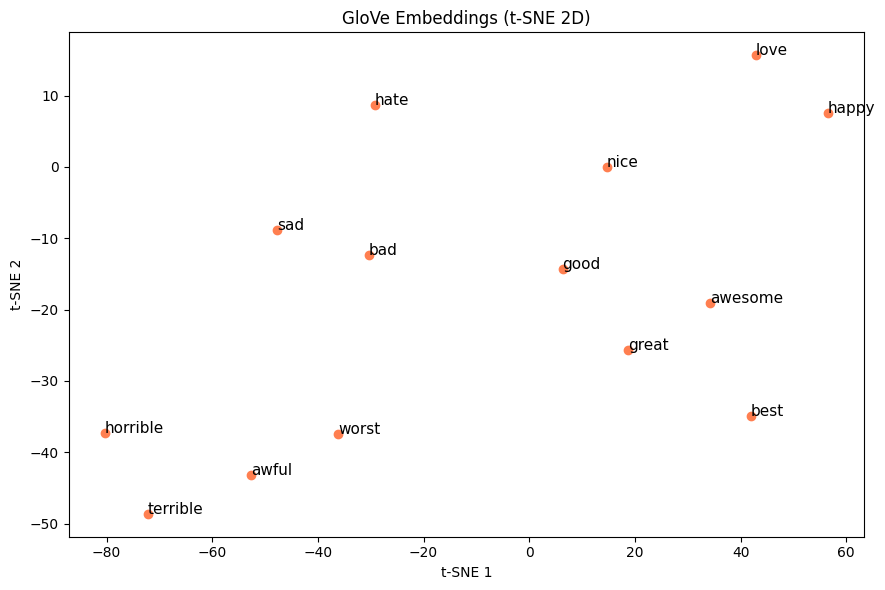

t-SNE plot saved.


In [22]:
# t-SNE on GloVe
from sklearn.manifold import TSNE

words_glove  = [w for w in words_to_plot if w in glove]
vecs_glove   = np.array([glove[w] for w in words_glove])

tsne         = TSNE(n_components=2, random_state=42, perplexity=5)
reduced_tsne = tsne.fit_transform(vecs_glove)

plt.figure(figsize=(9, 6))
plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1], color='coral')
for i, word in enumerate(words_glove):
    plt.annotate(word, (reduced_tsne[i, 0], reduced_tsne[i, 1]), fontsize=11)
plt.title('GloVe Embeddings (t-SNE 2D)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('glove_tsne.png', dpi=100)
plt.show()
print('t-SNE plot saved.')

## Module 2 Observations

**Results:**
- Word2Vec (FNN): Accuracy 0.5477, F1 0.5319
- GloVe (FNN): Accuracy 0.6209, F1 0.6211

GloVe beat Word2Vec because GloVe Twitter embeddings were pretrained on 27 billion tweets, so the vectors already match the language style of our dataset. Our Word2Vec was trained only on 45k tweets which is too small to learn good representations.

**Comparison with Module 1:**

1. **Semantic similarity.** Word2Vec and GloVe put similar words close in vector space. "happy" and "joyful" have similar vectors, unlike BoW.
2. **Dense vectors.** 100 dims, no zero values. More memory-efficient than sparse BoW vectors of 10,000 dims.
3. **Learned from context.** A word's meaning comes from surrounding words during training.
4. **GloVe > BoW on accuracy.** GloVe (0.6209) beat BoW (0.5760) and TF-IDF (0.5884) by using pretrained tweet knowledge.
5. **Still static.** One word has one vector regardless of sentence context. "bank" (finance) and "bank" (river) get the same vector.

---
# Module 3: Contextualized Word Embeddings

## BERT - Extract Frozen Embeddings

In [23]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

BERT_MODEL     = 'distilbert-base-uncased'
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
bert_encoder   = AutoModel.from_pretrained(BERT_MODEL).to(device)
bert_encoder.eval()
print('DistilBERT loaded on:', device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded on: cuda


In [24]:
def get_bert_embeddings(texts, batch_size=128):
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc   = bert_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=64,
            return_tensors='pt'
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = bert_encoder(**enc)
        cls_vecs = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_vecs.append(cls_vecs)
        if (i // batch_size + 1) % 20 == 0:
            print(f'  Processed {i + batch_size}/{len(texts)} samples...')
    return np.vstack(all_vecs)

print('Extracting BERT train embeddings...')
X_train_bert = get_bert_embeddings(X_train_raw)
print('Extracting BERT test embeddings...')
X_test_bert  = get_bert_embeddings(X_test_raw)
print('BERT embeddings shape:', X_train_bert.shape)

Extracting BERT train embeddings...
  Processed 2560/45615 samples...
  Processed 5120/45615 samples...
  Processed 7680/45615 samples...
  Processed 10240/45615 samples...
  Processed 12800/45615 samples...
  Processed 15360/45615 samples...
  Processed 17920/45615 samples...
  Processed 20480/45615 samples...
  Processed 23040/45615 samples...
  Processed 25600/45615 samples...
  Processed 28160/45615 samples...
  Processed 30720/45615 samples...
  Processed 33280/45615 samples...
  Processed 35840/45615 samples...
  Processed 38400/45615 samples...
  Processed 40960/45615 samples...
  Processed 43520/45615 samples...
Extracting BERT test embeddings...
  Processed 2560/12284 samples...
  Processed 5120/12284 samples...
  Processed 7680/12284 samples...
  Processed 10240/12284 samples...
BERT embeddings shape: (45615, 768)


In [25]:
print('Training FNN on frozen BERT embeddings...')
bert_acc, bert_prec, bert_rec, bert_f1, bert_preds = train_fnn(
    X_train_bert, X_test_bert, y_train, y_test, epochs=10, lr=1e-3
)
print(f'\n=== BERT Frozen Results ===')
print(f'Accuracy:  {bert_acc:.4f}')
print(f'Precision: {bert_prec:.4f}')
print(f'Recall:    {bert_rec:.4f}')
print(f'F1 Score:  {bert_f1:.4f}')
print(classification_report(y_test, bert_preds, zero_division=0))

Training FNN on frozen BERT embeddings...
  Epoch 5/10 | Loss: 0.6913
  Epoch 10/10 | Loss: 0.6425

=== BERT Frozen Results ===
Accuracy:  0.6641
Precision: 0.6643
Recall:    0.6641
F1 Score:  0.6626
              precision    recall  f1-score   support

           0       0.66      0.69      0.67      3972
           1       0.66      0.70      0.68      5937
           2       0.67      0.54      0.60      2375

    accuracy                           0.66     12284
   macro avg       0.66      0.64      0.65     12284
weighted avg       0.66      0.66      0.66     12284



## BERT - Fine-tuned (Second Contextual Model)

In [26]:
from torch.utils.data import Dataset
from torch.optim import AdamW

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

num_labels    = len(set(y_train))
train_dataset = TweetDataset(X_train_raw, y_train, bert_tokenizer)
test_dataset  = TweetDataset(X_test_raw,  y_test,  bert_tokenizer)
print(f'Dataset ready. Num labels: {num_labels}')

Dataset ready. Num labels: 3


In [27]:
# Load fresh model for fine-tuning
fine_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=num_labels
).to(device)

fine_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
optimizer_ft = AdamW(fine_model.parameters(), lr=2e-5)

EPOCHS_FT = 3

fine_model.train()
for epoch in range(EPOCHS_FT):
    total_loss = 0
    for batch in fine_loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)

        optimizer_ft.zero_grad()
        out  = fine_model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss = out.loss
        loss.backward()
        optimizer_ft.step()
        total_loss += loss.item()

    print(f'Epoch {epoch+1}/{EPOCHS_FT} | Loss: {total_loss/len(fine_loader):.4f}')

print('Fine-tuning done.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | Loss: 0.6853
Epoch 2/3 | Loss: 0.5396
Epoch 3/3 | Loss: 0.4264
Fine-tuning done.


In [28]:
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
fine_model.eval()

all_preds_ft = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        out       = fine_model(input_ids=input_ids, attention_mask=attn_mask)
        preds     = out.logits.argmax(dim=1).cpu().numpy()
        all_preds_ft.extend(preds)

ft_acc  = accuracy_score(y_test, all_preds_ft)
ft_prec = precision_score(y_test, all_preds_ft, average='weighted', zero_division=0)
ft_rec  = recall_score(y_test, all_preds_ft, average='weighted', zero_division=0)
ft_f1   = f1_score(y_test, all_preds_ft, average='weighted', zero_division=0)

print('=== Fine-tuned BERT Results ===')
print(f'Accuracy:  {ft_acc:.4f}')
print(f'Precision: {ft_prec:.4f}')
print(f'Recall:    {ft_rec:.4f}')
print(f'F1 Score:  {ft_f1:.4f}')
print(classification_report(y_test, all_preds_ft, zero_division=0))

=== Fine-tuned BERT Results ===
Accuracy:  0.6931
Precision: 0.6949
Recall:    0.6931
F1 Score:  0.6929
              precision    recall  f1-score   support

           0       0.73      0.65      0.69      3972
           1       0.69      0.72      0.71      5937
           2       0.66      0.69      0.67      2375

    accuracy                           0.69     12284
   macro avg       0.69      0.69      0.69     12284
weighted avg       0.69      0.69      0.69     12284



## Polysemy Check

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

# Word 'bank' has multiple meanings
poly_sentences = [
    "I went to the bank to deposit my salary.",
    "We sat by the river bank and watched the sunset.",
    "You can bank on me to finish this task.",
    "The bank approved my loan application today.",
    "The fish swam near the muddy river bank."
]

def get_word_embedding_in_context(sentence, word, tokenizer, model):
    enc    = tokenizer(sentence, return_tensors='pt').to(device)
    tokens = tokenizer.tokenize(sentence)
    with torch.no_grad():
        out    = model(**enc)
    hidden = out.last_hidden_state[0]   # (seq_len, hidden_dim)

    # Find index of target word (account for [CLS] offset)
    for i, tok in enumerate(tokens):
        if word.lower() in tok.lower():
            return hidden[i + 1].cpu().numpy()
    return None

bert_encoder.eval()
poly_vecs = []
for sent in poly_sentences:
    vec = get_word_embedding_in_context(sent, 'bank', bert_tokenizer, bert_encoder)
    if vec is not None:
        poly_vecs.append(vec)
    else:
        print(f'Word not found in: {sent}')

print(f'Got {len(poly_vecs)} embeddings for "bank"')

Got 5 embeddings for "bank"


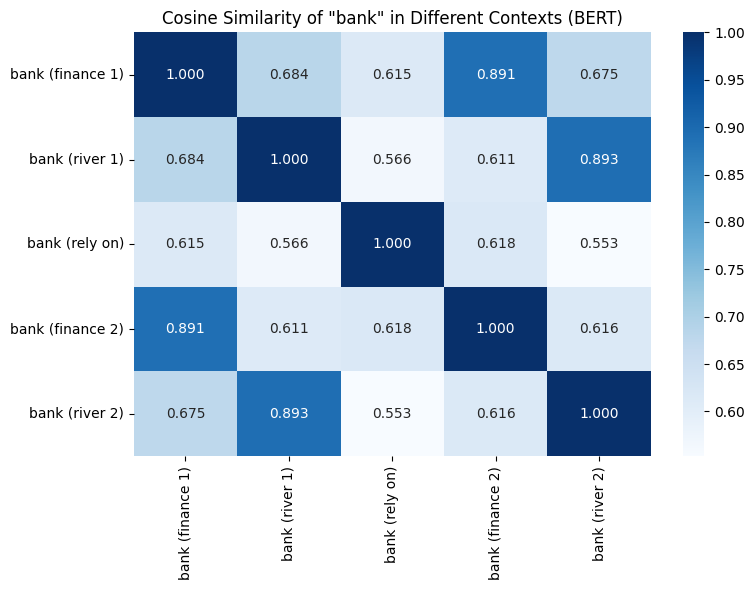


Observation:
Finance sentences score high similarity to each other.
River sentences score high similarity to each other.
Finance vs River sentences score lower similarity.
This proves BERT gives DIFFERENT vectors for the same word based on context.


In [30]:
poly_vecs_arr = np.array(poly_vecs)
sim_matrix    = cosine_similarity(poly_vecs_arr)

row_labels = [
    'bank (finance 1)',
    'bank (river 1)',
    'bank (rely on)',
    'bank (finance 2)',
    'bank (river 2)'
][:len(poly_vecs)]

plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_matrix,
    xticklabels=row_labels,
    yticklabels=row_labels,
    annot=True,
    fmt='.3f',
    cmap='Blues'
)
plt.title('Cosine Similarity of "bank" in Different Contexts (BERT)')
plt.tight_layout()
plt.savefig('polysemy_heatmap.png', dpi=100)
plt.show()

print('\nObservation:')
print('Finance sentences score high similarity to each other.')
print('River sentences score high similarity to each other.')
print('Finance vs River sentences score lower similarity.')
print('This proves BERT gives DIFFERENT vectors for the same word based on context.')

## Module 3 Observations

**Results:**
- BERT frozen embeddings + FNN: Accuracy 0.6641, F1 0.6626
- BERT fine-tuned: Accuracy 0.6931, F1 0.6929

Fine-tuned BERT gave the best result across all modules. Even frozen BERT (0.6641) beat GloVe (0.6209), showing that contextual embeddings are richer even without task-specific training.

**Comparison with Module 1 and Module 2:**

1. **Context-aware.** BERT gives a different vector for "bank" in a financial sentence vs. a river sentence. Word2Vec cannot do this. This was confirmed in the polysemy check.
2. **Best accuracy.** Fine-tuned BERT (0.6931) is the highest across all 7 models.
3. **High compute cost.** BERT extraction took several minutes even on T4 GPU. Fine-tuning took 3 epochs with clear loss drop: 0.6853 → 0.5396 → 0.4264.
4. **No out-of-vocabulary problem.** BERT uses subword tokenization so unknown words are always handled.
5. **Attention mechanism.** Every word attends to every other word, capturing long-range dependencies.

---
# Final Comparison

In [31]:
results = {
    'Module': [
        'M1 - BoW',
        'M1 - TF-IDF',
        'M1 - Co-occurrence',
        'M2 - Word2Vec (FNN)',
        'M2 - GloVe (FNN)',
        'M3 - BERT (frozen)',
        'M3 - BERT (fine-tuned)'
    ],
    'Type': [
        'Frequency',
        'Frequency',
        'Frequency',
        'Prediction',
        'Prediction',
        'Contextual',
        'Contextual'
    ],
    'Accuracy': [
        bow_acc, tfidf_acc, cooc_acc,
        w2v_acc, glove_acc,
        bert_acc, ft_acc
    ],
    'F1 Score': [
        bow_f1, tfidf_f1, cooc_f1,
        w2v_f1, glove_f1,
        bert_f1, ft_f1
    ]
}

df_results = pd.DataFrame(results)
df_results['Accuracy'] = df_results['Accuracy'].round(4)
df_results['F1 Score'] = df_results['F1 Score'].round(4)

print(df_results.to_string(index=False))

                Module       Type  Accuracy  F1 Score
              M1 - BoW  Frequency    0.5760    0.5704
           M1 - TF-IDF  Frequency    0.5884    0.5761
    M1 - Co-occurrence  Frequency    0.4851    0.4309
   M2 - Word2Vec (FNN) Prediction    0.5477    0.5319
      M2 - GloVe (FNN) Prediction    0.6209    0.6211
    M3 - BERT (frozen) Contextual    0.6641    0.6626
M3 - BERT (fine-tuned) Contextual    0.6931    0.6929


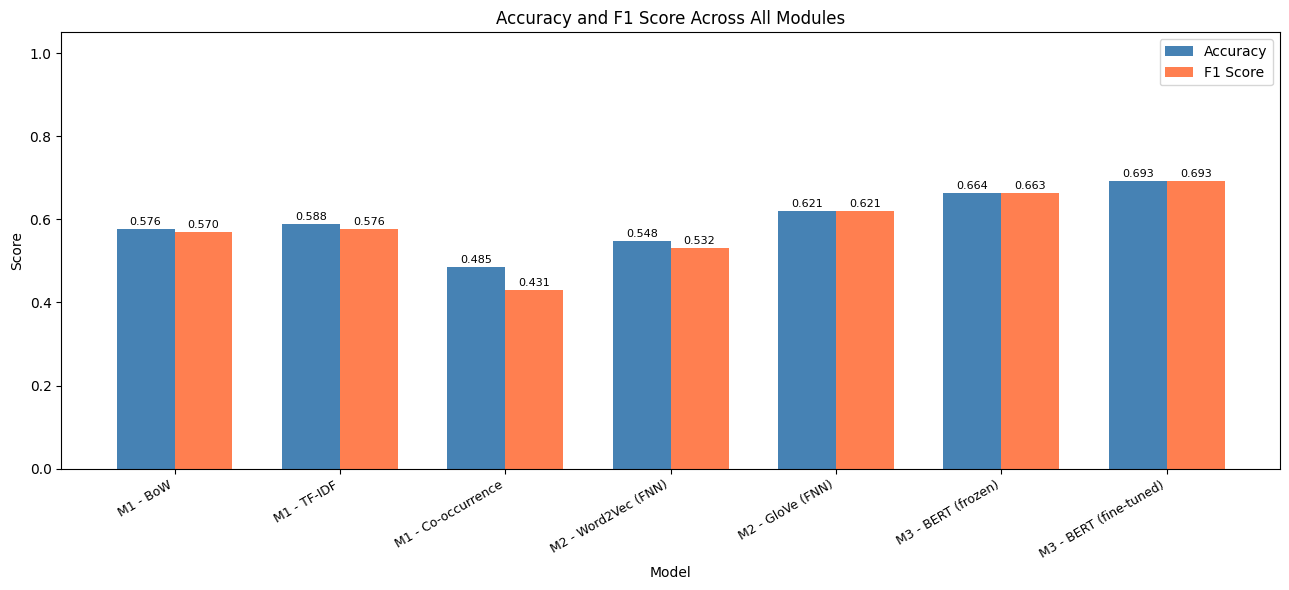

Comparison chart saved.


In [32]:
fig, ax = plt.subplots(figsize=(13, 6))

x     = np.arange(len(df_results))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['Accuracy'], width, label='Accuracy',  color='steelblue')
bars2 = ax.bar(x + width/2, df_results['F1 Score'], width, label='F1 Score', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Accuracy and F1 Score Across All Modules')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Module'], rotation=30, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 1.05)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=100)
plt.show()
print('Comparison chart saved.')

## Summary Table

| Module | Technique | Accuracy | F1 Score | Key Observation |
|--------|-----------|----------|----------|-----------------|
| M1 - BoW | Frequency | 0.5760 | 0.5704 | Fast, sparse, no semantics |
| M1 - TF-IDF | Frequency | 0.5884 | 0.5761 | Best in Module 1, weights rare words |
| M1 - Co-occurrence | Frequency | 0.4851 | 0.4309 | Weak on short tweets |
| M2 - Word2Vec | Prediction | 0.5477 | 0.5319 | Static vectors, small training set |
| M2 - GloVe | Prediction | 0.6209 | 0.6211 | Strong pretrained tweet vectors |
| M3 - BERT frozen | Contextual | 0.6641 | 0.6626 | Good without fine-tuning |
| M3 - BERT fine-tuned | Contextual | **0.6931** | **0.6929** | Best overall |

## Final Analysis

**Which model performed best?**
Fine-tuned BERT with accuracy 0.6931 and F1 0.6929.

**Why?**
BERT was pretrained on massive text using masked language modeling. It already understands language before fine-tuning. The attention mechanism reads the full sentence at once so word meaning is always based on context. Three epochs of fine-tuning on our Twitter data reduced the loss from 0.6853 to 0.4264, showing strong adaptation to the task.

**Trade-offs:**

| Factor | Module 1 | Module 2 | Module 3 |
|--------|----------|----------|----------|
| Speed | Very fast | Moderate | Slow |
| Memory | Low | Low | High |
| Accuracy | 0.58 best | 0.62 best | 0.69 best |
| Complexity | Simple | Moderate | Complex |
| Context-aware | No | No | Yes |
| Semantic similarity | No | Yes | Yes |
| GPU needed | No | No | Yes |